# Analyse Exploratoire des Données

## Objectif

L'objectif est d'explorer le dataset afin de comprendre sa structure,
détecter les valeurs manquantes, les doublons, les distributions des variables
et préparer les données pour les étapes de prétraitement et de modélisation.

## 1)Importation des bibliothèques :

In [2]:
# Installer matplotlib pour résoudre l'erreur d'importation
%pip install matplotlib --quiet

# Installer matplotlib et pandas pour résoudre l'erreur d'importation
%pip install matplotlib pandas --quiet

%pip install seaborn missingno

import sys
print(sys.executable)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import glob

sns.set(style="darkgrid")


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
/usr/local/bin/python3.11


## 2) Chargement des fichiers CSV

In [3]:
path = "dataset/*.csv"

files = glob.glob(path)

data_list = [pd.read_csv(f) for f in files]

## 3) Dimensions de chaque fichier

In [6]:
import os

for file, df in zip(files, data_list):
    filename = os.path.basename(file)
    print(f"{filename} : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv : 288602 lignes, 79 colonnes
Monday-WorkingHours.pcap_ISCX.csv : 529918 lignes, 79 colonnes
Friday-WorkingHours-Morning.pcap_ISCX.csv : 191033 lignes, 79 colonnes
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv : 286467 lignes, 79 colonnes
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv : 225745 lignes, 79 colonnes
Tuesday-WorkingHours.pcap_ISCX.csv : 445909 lignes, 79 colonnes
Wednesday-workingHours.pcap_ISCX.csv : 692703 lignes, 79 colonnes
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv : 170366 lignes, 79 colonnes


## 4) Fusion des datasets

In [20]:

data = pd.concat(data_list)
rows, cols = data.shape

print('Nouvelle dimension')
print(f'Nombre de lignes: {rows}')
print(f'Nombre de colonnes: {cols}')
print(f'Total de cellules: {rows * cols}')

Nouvelle dimension
Nombre de lignes: 2830743
Nombre de colonnes: 79
Total de cellules: 223628697


## 5) Informations générales

In [21]:
data.info()

<class 'pandas.DataFrame'>
Index: 2830743 entries, 0 to 170365
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max                 int64  
 

## 6) Statistiques descriptives

In [25]:
pd.options.display.max_rows = 80

print('Overview of Columns:')
data.describe().transpose()

Overview of Columns:


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.000000e+00,53.000000,80.000000,4.430000e+02,6.553500e+04
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-1.300000e+01,155.000000,31316.000000,3.204828e+06,1.200000e+08
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.000000e+00,2.000000,2.000000,5.000000e+00,2.197590e+05
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.000000e+00,1.000000,2.000000,4.000000e+00,2.919220e+05
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.000000e+00,12.000000,62.000000,1.870000e+02,1.290000e+07
Total Length of Bwd Packets,2830743.0,1.616264e+04,2.263088e+06,0.000000e+00,0.000000,123.000000,4.820000e+02,6.554530e+08
Fwd Packet Length Max,2830743.0,2.075999e+02,7.171848e+02,0.000000e+00,6.000000,37.000000,8.100000e+01,2.482000e+04
Fwd Packet Length Min,2830743.0,1.871366e+01,6.033935e+01,0.000000e+00,0.000000,2.000000,3.600000e+01,2.325000e+03
Fwd Packet Length Mean,2830743.0,5.820194e+01,1.860912e+02,0.000000e+00,6.000000,34.000000,5.000000e+01,5.940857e+03
Fwd Packet Length Std,2830743.0,6.891013e+01,2.811871e+02,0.000000e+00,0.000000,0.000000,2.616295e+01,7.125597e+03


## 7) Valeurs manquantes

In [29]:
missing_values = pd.DataFrame({
    "Column": data.columns,
    "Missing Values": data.isnull().sum().values
})

missing_values

,Column,Missing Values
0,Destination Port,0
1,Flow Duration,0
2,Total Fwd Packets,0
3,Total Backward Packets,0
4,Total Length of Fwd Packets,0
5,Total Length of Bwd Packets,0
6,Fwd Packet Length Max,0
7,Fwd Packet Length Min,0
8,Fwd Packet Length Mean,0
9,Fwd Packet Length Std,0


## importtion de dataset  fusionné

In [ ]:
# Créer le dossier processed si nécessaire
import os

os.makedirs("../data/processed", exist_ok=True)

# Sauvegarder le dataset fusionné
data.to_csv("data/processed/merged_dataset.csv", index=False)

print("Dataset fusionné enregistré avec succès.")

Dataset fusionné enregistré avec succès.


## 8) Détection des doublons

In [33]:
doublons = data.duplicated().sum()
print(f"Nombre de lignes dupliquées : {doublons}")
print(f"Pourcentage de doublons : {doublons / len(data) * 100:.2f} %")

# Suppression des doublons (à exécuter si nécessaire)
# data = data.drop_duplicates()
# print(f"Nouvelle dimension après suppression : {data.shape}")

Nombre de lignes dupliquées : 308381
Pourcentage de doublons : 10.89 %


## 9) Distribution de la variable cible (Label)

Colonnes contenant 'Label' : ['Label']
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Label
BENIGN                        80.300366
DoS Hulk                       8.162981
PortScan                       5.614427
DDoS                           4.522735
DoS GoldenEye                  0.363615
FTP-Patator                    0.280421
SSH-Patator                    0.208320
DoS slowloris                  0.204752
DoS Slowhttptest               0

/var/folders/31/grd46s814xv73h8k641rncwm0000gn/T/ipykernel_52047/1250415282.py:13: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
/Users/macair/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


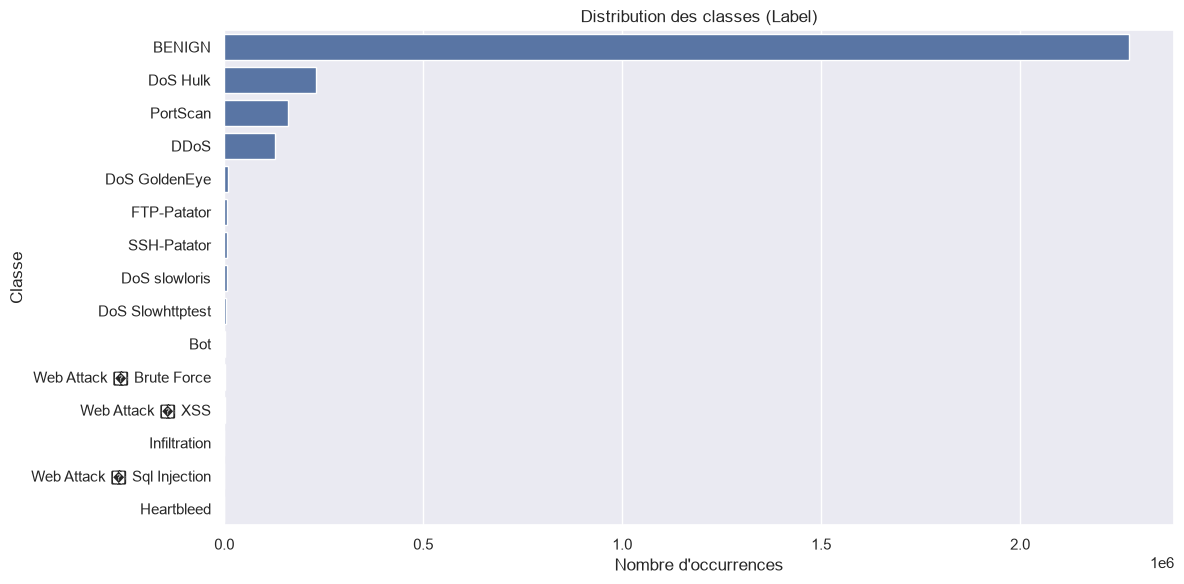

In [35]:
data.columns = data.columns.str.strip()

print("Colonnes contenant 'Label' :", [c for c in data.columns if 'Label' in c])
print(data['Label'].value_counts())
print()
print(data['Label'].value_counts(normalize=True) * 100)

plt.figure(figsize=(12, 6))
sns.countplot(y=data['Label'], order=data['Label'].value_counts().index)
plt.title("Distribution des classes (Label)")
plt.xlabel("Nombre d'occurrences")
plt.ylabel("Classe")
plt.tight_layout()
plt.show()

## 10) Valeurs infinies et aberrantes

In [36]:
# Colonnes numériques uniquement
num_cols = data.select_dtypes(include=[np.number]).columns

inf_counts = np.isinf(data[num_cols]).sum()
inf_counts = inf_counts[inf_counts > 0]
print("Colonnes contenant des valeurs infinies :")
print(inf_counts)

# Remplacement des valeurs infinies par NaN pour les traiter comme valeurs manquantes
data[num_cols] = data[num_cols].replace([np.inf, -np.inf], np.nan)

print(f"\nValeurs manquantes après traitement des infinis :")
print(data.isnull().sum()[data.isnull().sum() > 0])

Colonnes contenant des valeurs infinies :
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64

Valeurs manquantes après traitement des infinis :
Flow Bytes/s      2867
Flow Packets/s    2867
dtype: int64


## 11) Colonnes constantes

In [37]:
constant_cols = [col for col in data.columns if data[col].nunique() == 1]
print(f"Nombre de colonnes constantes : {len(constant_cols)}")
print(constant_cols)

# Ces colonnes n'apportent aucune information pour la modélisation
# data = data.drop(columns=constant_cols)

Nombre de colonnes constantes : 8
['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


## 12) Visualisation des valeurs manquantes (missingno)

<Figure size 1200x600 with 0 Axes>

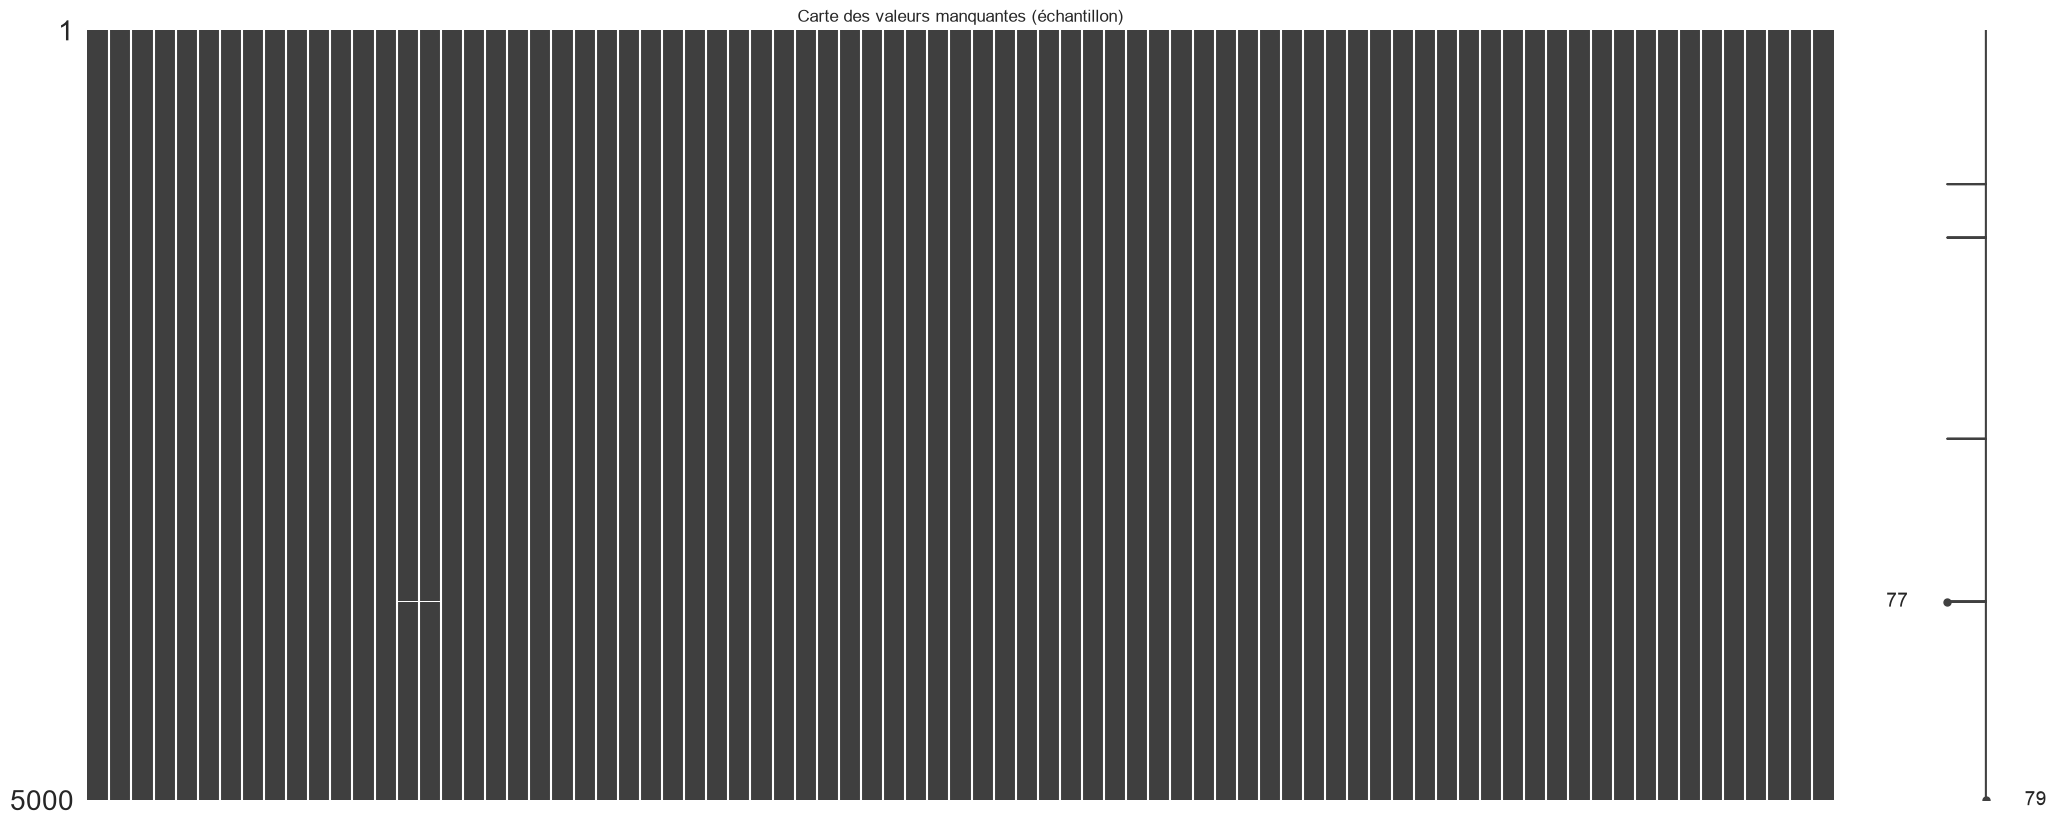

In [38]:
plt.figure(figsize=(12, 6))
msno.matrix(data.sample(5000))  # échantillon pour la lisibilité
plt.title("Carte des valeurs manquantes (échantillon)")
plt.show()

## 13) Matrice de corrélation

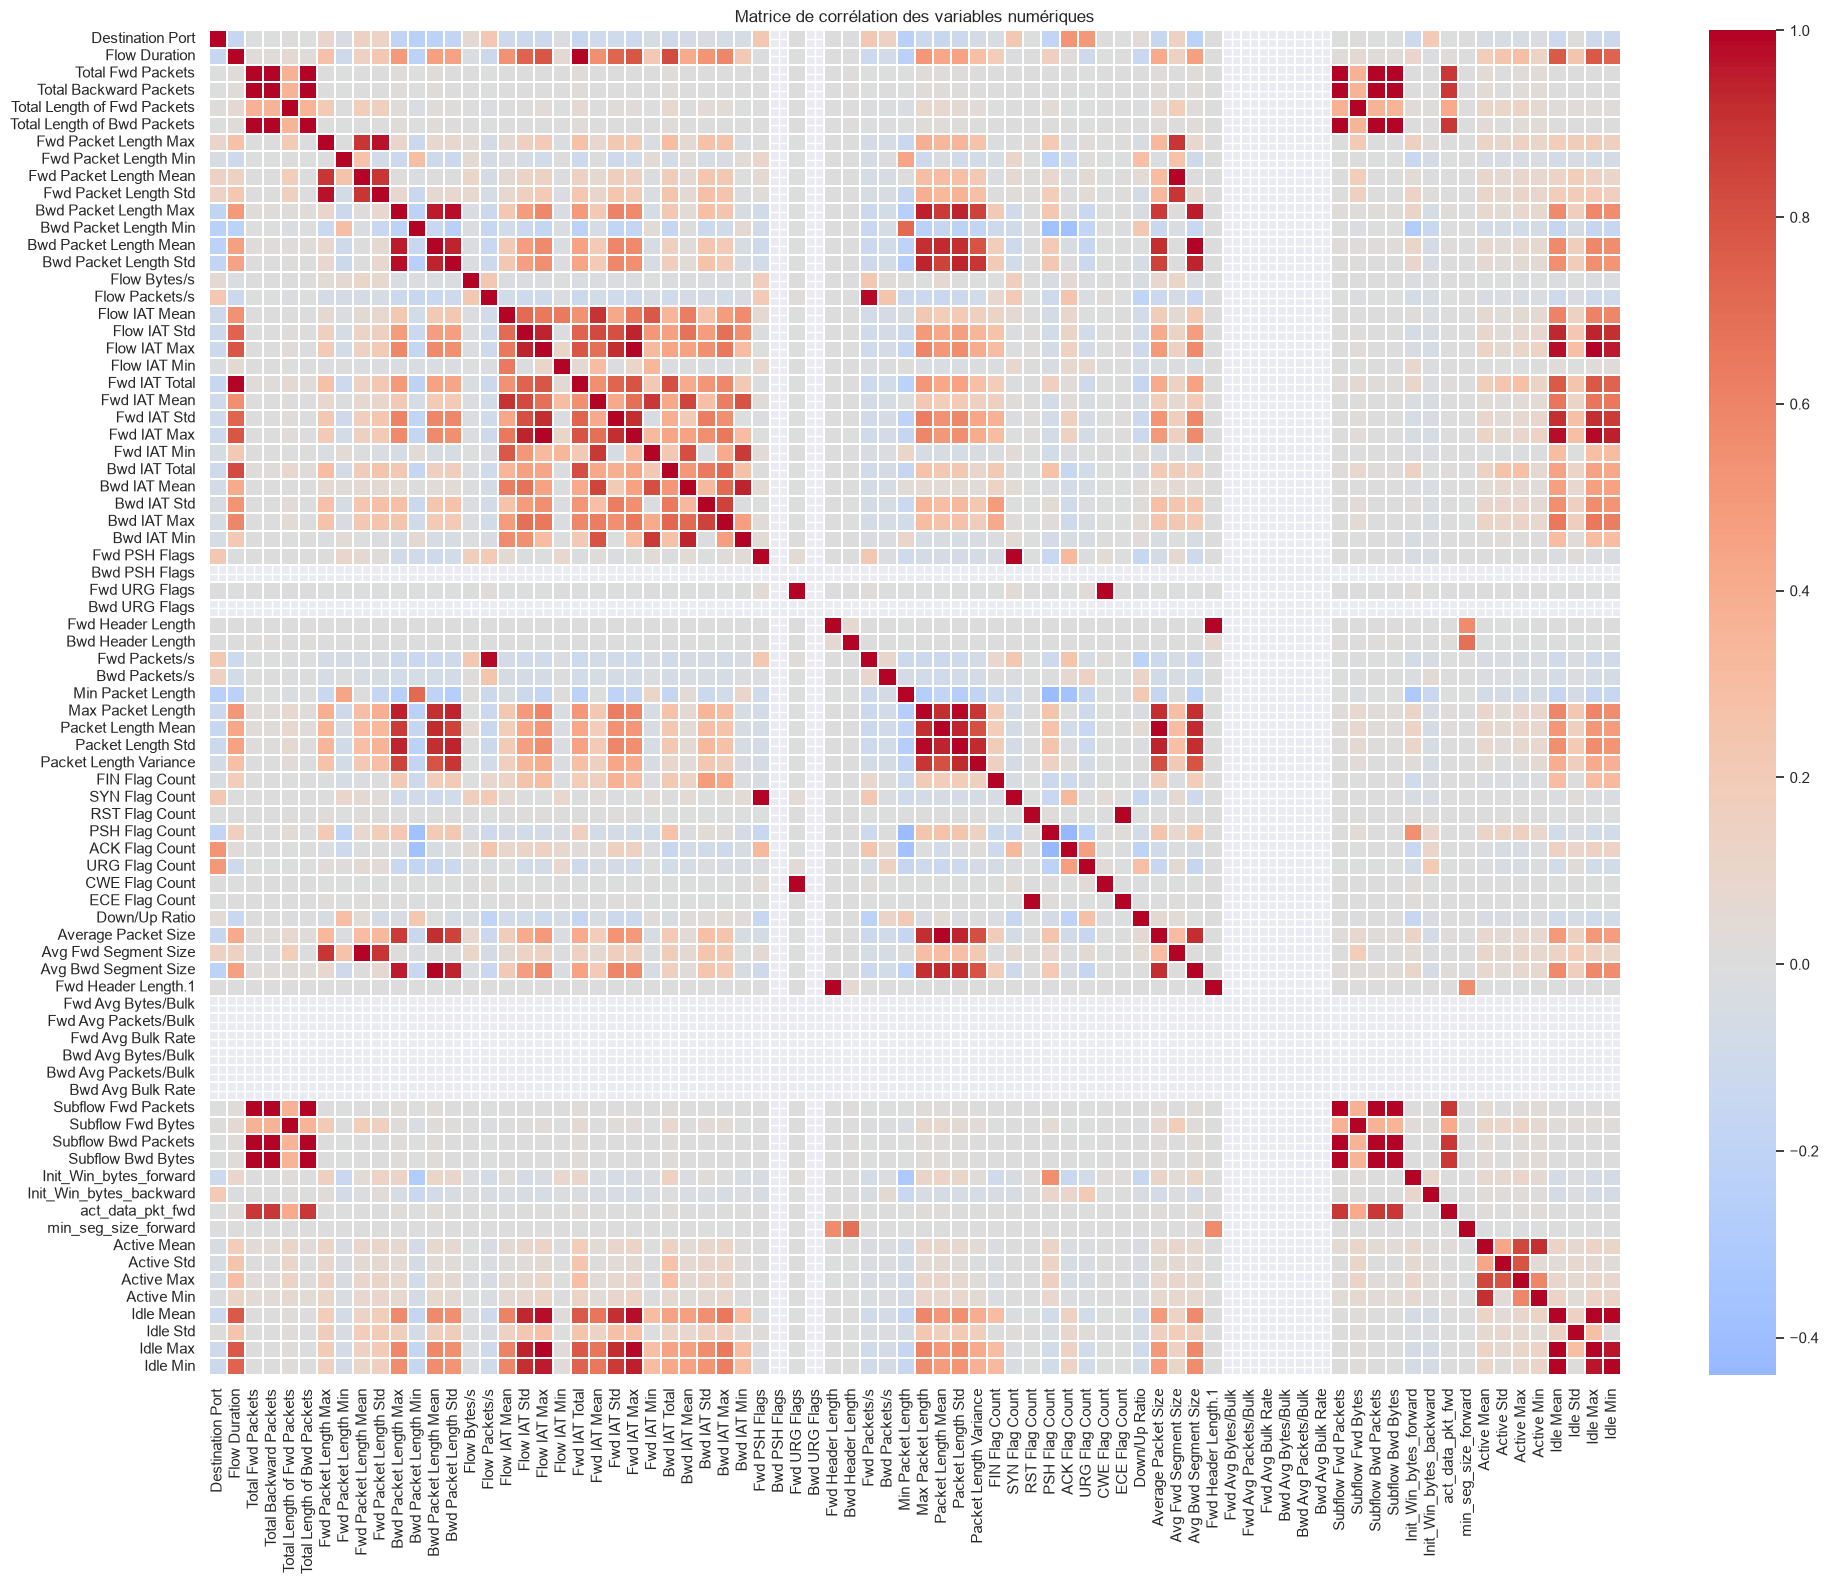

Paires de variables fortement corrélées (>0.9) :
Avg Bwd Segment Size         Bwd Packet Length Mean         1.000000
Subflow Bwd Bytes            Total Length of Bwd Packets    1.000000
Subflow Fwd Bytes            Total Length of Fwd Packets    0.999999
Subflow Bwd Packets          Total Fwd Packets              0.999070
Fwd IAT Total                Flow Duration                  0.998560
Flow IAT Max                 Fwd IAT Max                    0.998084
RST Flag Count               ECE Flag Count                 0.997820
Average Packet Size          Packet Length Mean             0.997790
Total Length of Bwd Packets  Total Fwd Packets              0.996993
Total Fwd Packets            Subflow Bwd Bytes              0.996987
Total Length of Bwd Packets  Total Backward Packets         0.994429
Total Backward Packets       Subflow Bwd Bytes              0.994424
Idle Max                     Idle Mean                      0.990387
Idle Min                     Idle Mean                

In [39]:
plt.figure(figsize=(20, 16))
corr = data[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.1)
plt.title("Matrice de corrélation des variables numériques")
plt.tight_layout()
plt.show()

# Paires fortement corrélées (redondance potentielle)
seuil = 0.9
strong_corr = corr.abs().unstack().sort_values(ascending=False)
strong_corr = strong_corr[(strong_corr < 1) & (strong_corr > seuil)]
print("Paires de variables fortement corrélées (>0.9) :")
print(strong_corr.drop_duplicates())